# Analysis of Competitive Dominance in Modern CS2 Esports
This project analyzes competitive Counter-Strike 2 (CS2) esports matches from S-tier tournaments between late 2023 and 2026 using data collected from the bo3.gg API.
The goal of this analysis is to explore which teams have been the most dominant in the modern CS2 era by examining winrates, total match activity, and overall competitive performance.
Because S-tier tournaments represent the highest level of professional CS2 competition, focusing on these events allows the dataset to better reflect the strongest teams and the most meaningful matches.
Additionally, this project investigates whether stronger teams perform more consistently in longer match formats such as BO1, BO3 and BO5.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("cs2_s_tier_matches.csv")
df

,id,team1_name,team2_name,winner_name,team1_score,team2_score,bo_format,start_date,tournament_id,slug,...,parsed_status,tier,tier_rank,position,team1_last_game_score,team2_last_game_score,game_version,team1_win,team2_win,match_name
0,119817,3Dmax,Mibr,Mibr,0.0,1.0,BO1,2026-05-20 03:15:00+00:00,4208,3dmax-vs-mibr-20-05-2026,...,done,s,1,11.0,NaN,NaN,2.0,False,True,3dmax-vs-mibr
1,119816,Parivision,Liquid,Parivision,1.0,0.0,BO1,2026-05-20 03:15:00+00:00,4208,parivision-vs-liquid-20-05-2026,...,done,s,1,12.0,NaN,NaN,2.0,True,False,parivision-vs-liquid
2,119818,The Mongolz,Lynn Vision,The Mongolz,1.0,0.0,BO1,2026-05-20 04:20:00+00:00,4208,the-mongolz-vs-lynn-vision-20-05-2026,...,done,s,1,8.0,NaN,NaN,2.0,True,False,the-mongolz-vs-lynn-vision
3,119819,B8,Nip,B8,1.0,0.0,BO1,2026-05-20 04:25:00+00:00,4208,b8-vs-nip-20-05-2026,...,done,s,1,9.0,NaN,NaN,2.0,True,False,b8-vs-nip
4,119813,Mousesports,Tyloo,Tyloo,0.0,1.0,BO1,2026-05-20 05:15:00+00:00,4208,mousesports-vs-tyloo-cs-go-20-05-2026,...,done,s,1,12.0,NaN,NaN,2.0,False,True,mousesports-vs-tyloo-cs-go
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,36867,Betboom,Complexity,Complexity,0.0,2.0,BO3,2023-10-20 05:30:00+00:00,1589,betboom-vs-complexity-20-10-2023,...,done,s,1,5.0,11.0,13.0,2.0,False,True,betboom-vs-complexity
2107,36868,Ence,Faze,Faze,0.0,2.0,BO3,2023-10-20 08:30:00+00:00,1589,ence-vs-faze-20-10-2023,...,done,s,1,3.0,0.0,12.0,2.0,False,True,ence-vs-faze
2108,36869,Complexity,G2,Complexity,2.0,0.0,BO3,2023-10-21 05:30:00+00:00,1589,complexity-vs-g2-21-10-2023,...,done,s,1,4.0,13.0,3.0,2.0,True,False,complexity-vs-g2
2109,36870,Faze,Mousesports,Faze,2.0,0.0,BO3,2023-10-21 08:30:00+00:00,1589,faze-vs-mousesports-21-10-2023,...,done,s,1,2.0,13.0,9.0,2.0,True,False,faze-vs-mousesports


## Dataset Overview

The dataset contains professional matches from finished S-tier tournaments, which represent the highest level of CS2 competition.

Each row represents a single match and includes:
- participating teams
- winners
- match scores
- tournament IDs
- match formats (BO1, BO3, BO5)

To focus on the modern CS2 era, only tournaments from late 2023 onward were included.

In [6]:
print(df.shape)

(2111, 30)


## Constructing a Team-Level Dataset

The original dataset stores matches with two teams per row. To analyze team performance more effectively, the dataset was transformed into a team-level format where each row represents one team's perspective of a match.

This allows team winrates and match activity to be calculated more easily.

In [6]:
# Create a team-level dataset to calculate win rates
team1_df = pd.DataFrame({"team": df["team1_name"], "opponent": df["team2_name"],
                         "won": (df["winner_team_id"] == df["team1_id"]).astype(int),
                         "bo_format": df["bo_format"], 
                         "start_date": df["start_date"]})

team2_df = pd.DataFrame({"team": df["team2_name"], "opponent": df["team1_name"], 
                         "won": (df["winner_team_id"] == df["team2_id"]).astype(int),
                         "bo_format": df["bo_format"],
                         "start_date": df["start_date"]})
team_level_df = pd.concat([team1_df, team2_df], ignore_index=True)

# Calculate team_level win rates and keep only teams with large number of matches
team_stats = (team_level_df.groupby("team").agg(matches_played=("won", "count"), wins=("won", "sum"), winrate=("won", "mean")).reset_index())
team_stats = team_stats[team_stats["matches_played"] >= 20].copy()  # Keep only teams with at least 20 matches
# Then sort by win rate
team_stats = team_stats.sort_values("winrate",ascending=False)

In [7]:
team_level_df.head()

,team,opponent,won,bo_format,start_date
0,3Dmax,Mibr,0,BO1,2026-05-20 03:15:00+00:00
1,Parivision,Liquid,1,BO1,2026-05-20 03:15:00+00:00
2,The Mongolz,Lynn Vision,1,BO1,2026-05-20 04:20:00+00:00
3,B8,Nip,1,BO1,2026-05-20 04:25:00+00:00
4,Mousesports,Tyloo,0,BO1,2026-05-20 05:15:00+00:00


In [13]:
team_stats.head()

,team,matches_played,wins,winrate
97,Vitality,178,132,0.741573
87,Spirit,159,110,0.691824
63,Mousesports,190,117,0.615789
65,Natus Vincere,171,104,0.608187
90,The Mongolz,156,93,0.596154


## Team Winrate vs Match Activity

One important question is whether the strongest teams are also the most active teams.

The following visualization compares overall winrate against total matches played. Teams located in the upper-right region of the graph demonstrate both high activity and strong competitive performance, indicating sustained dominance across multiple S-tier tournaments.

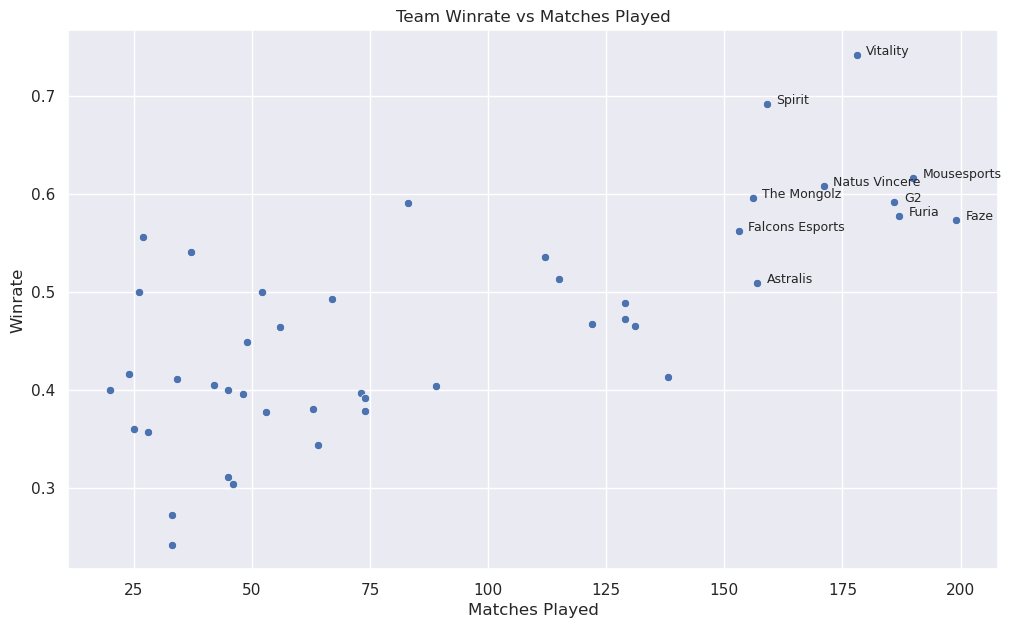

In [9]:
top_teams = team_stats[team_stats["matches_played"] >= 150]  # teams that have more than 150 matchess

plt.figure(figsize=(12,7))

sns.set_theme(style="darkgrid")
sns.scatterplot(data=team_stats, x="matches_played", y="winrate")

for _, row in top_teams.iterrows():
    plt.text(row["matches_played"] + 2, row["winrate"], row["team"], fontsize=9)  # Add team names to the plot

plt.title("Team Winrate vs Matches Played")
plt.xlabel("Matches Played")
plt.ylabel("Winrate")
plt.show()

The visualization suggests that a relatively small group of elite teams dominates modern CS2 competition.

Vitality stands out as the strongest overall team due to its combination of extremely high match activity and the highest winrate among heavily active teams. Spirit also demonstrates exceptional performance with a similarly strong winrate.

Teams such as FaZe, G2, NAVI, and The Mongolz remain highly competitive, although their overall winrates are slightly lower.

## Teams with the Most Match Wins

While winrate measures efficiency, total match wins can better represent long-term consistency and dominance in top-level tournaments.

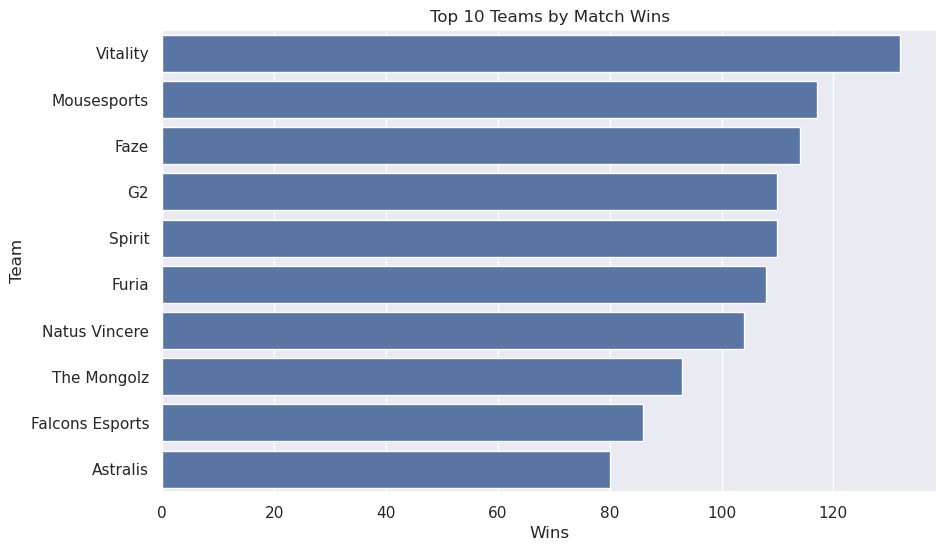

In [11]:
top_winners = (df["winner_name"].value_counts().head(10))
plt.figure(figsize=(10,6))
sns.barplot(x=top_winners.values, y=top_winners.index)

plt.title("Top 10 Teams by Match Wins")
plt.xlabel("Wins")
plt.ylabel("Team")
plt.show()

## Do Top Teams Perform Better in Longer Series?

Best-of-one (BO1) matches are often considered more volatile because weaker teams have a greater chance of pulling off upset victories in a single map.

Longer formats such as BO3 and BO5 may better reflect overall team strength because stronger teams have more opportunities to adapt and recover during a series.

In [14]:
elite_teams = ["Vitality", "Mousesports", "FaZe", "G2", "Spirit", "Furia", "Natus Vincere"]
elite_matches = team_level_df[team_level_df["team"].isin(elite_teams)]

bo_winrates = (elite_matches.groupby("bo_format")["won"].mean().reset_index())
bo_winrates

,bo_format,won
0,BO1,0.721649
1,BO3,0.631407
2,BO5,0.561404


Contrary to my initial expectation, elite teams achieved the highest average winrate in BO1 matches. One possible explanation is that elite teams are often heavily favored against weaker opponents during group stages and opening rounds, where BO1 matches are more common. In contrast, BO3 and BO5 matches frequently occur later in tournaments against stronger opposition, making victories more difficult despite the longer format.

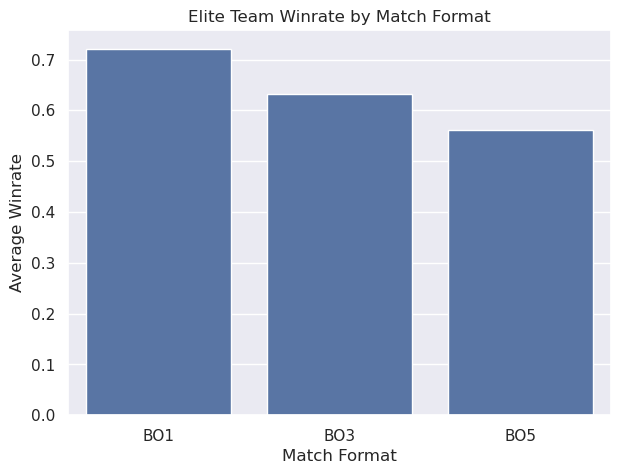

In [20]:
plt.figure(figsize=(7,5))
sns.barplot(data=bo_winrates, x="bo_format", y="won")

plt.title("Elite Team Winrate by Match Format")
plt.xlabel("Match Format")
plt.ylabel("Average Winrate")

plt.show()

At first, I expected elite teams to perform better in longer series formats such as BO3 and BO5 because these formats provide more opportunities for stronger teams to adapt and redeem themselves from mistakes. In professional CS2, teams do not always perform at their best immediately on the first game. Some teams may start a match slowly, need time to understand their opponent's statics, or require additional maps to fully demonstrate the depth of their map pool and strategic preparation.

Interestingly, the results showed the opposite pattern. Elite teams achieved their highest average winrate in BO1 matches, followed by BO3 and then BO5 matches. One possible explanation is that BO1 matches are often played during earlier tournament stages where elite teams frequently face weaker opponents. In contrast, BO3 and BO5 matches usually occur deeper into tournaments against stronger competition, making victories more difficult even for top teams.


## Discussion

Overall, the analysis suggests that modern CS2 competition is dominated by a relatively small group of elite organizations.

Vitality and Mousesports appear to be the strongest teams overall due to their combination of high activity and consistently strong winrates. Other organizations such as FaZe, NAVI, and G2 remain highly competitive across large numbers of matches.

The analysis also suggests that longer match formats may better reflect true team strength, since elite teams appear to perform more consistently in BO3 and BO5 matches compared to BO1 games.

## Reflection

I learned that collecting esports data is much more difficult than I initially expected. Many popular websites such as HLTV restrict automated scraping through robots.txt, which likely helps protect their servers and prevents excessive automated traffic. As a result, I had to spend significant time searching for alternative data source (Bo3.gg) and understanding the structure of different APIs.

Some API endpoints returned outdated or repeated legacy CS:GO matches from 2020, which required additional filtering and debugging. Another challenge involved cleaning inconsistent team names and tournament information as well.

Another lesson I learned is that data collection often takes much longer than the actual analysis. A large portion of this project involved debugging API requests, cleaning inconsistent team names, filtering outdated matches, and restructuring the dataset into a usable format. My original goal was to investigate whether specific maps could predict match outcomes, but data limitations forced me to adjust my approach. Instead, I focused on match formats (BO1, BO3, and BO5), which still allowed me to explore how the number of maps played relates to team performance while working with a more reliable dataset.